<a href="https://colab.research.google.com/github/katarinako01/DL_image_segmentation/blob/main/image_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Urban scene segmentation with U-Net using OpenImages

**Author:** Katarina Koiro  
**Description:** Semantic segmentation of urban scenes with 6 classes (Background, Person, Car, Bus, Traffic lights, Skyscraper) using OpenImages V5 segmentation masks.  

**Dataset:** OpenImages V5 (dense segmentation masks)  
- Masks: One PNG per object instance; combined to form semantic masks per image  
- Classes mapped to IDs 0–5  

**Model:** U-Net with ResNet34 encoder pretrained on ImageNet  
**Loss:** Dice + Weighted Cross-Entropy  
**Evaluation:** Accuracy, Precision, Recall, F1 on 100 unseen images

In [1]:
# libraries
#import fiftyone as fo
#import fiftyone.zoo as foz
import os
import csv
import time
import io
import random
import zipfile
import pickle
from collections import defaultdict
from itertools import combinations
from concurrent.futures import ThreadPoolExecutor, as_completed
import urllib.request
import requests
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from google.colab import drive

In [2]:
# to store and save dowloaded files
# won't mount yet, no need to download this -> mainly needed for exploration purposes
DATA_DIR = "/content/data/raw"
os.makedirs(DATA_DIR, exist_ok=True)

In [3]:
# f-ion to find MID for a class of interest
def search_classes(keywords):
    desc_path = os.path.join(DATA_DIR, "class-descriptions.csv")

    if not os.path.exists(desc_path):
        urllib.request.urlretrieve(
            "https://storage.googleapis.com/openimages/v7/oidv7-class-descriptions.csv",
            desc_path
        )

    results = []

    with open(desc_path, "r") as f:
        reader = csv.reader(f)

        for row in reader:
            mid, name = row[0], row[1]

            for kw in keywords:
                if kw.lower() == name.lower():
                    results.append((mid, name))

    return results

In [4]:
matches = search_classes(["Person", "Car", "Traffic light", "Tree"])

for mid, name in matches:
    print(f"{name} → {mid}")

Car → /m/0k4j
Person → /m/01g317
Traffic light → /m/015qff
Tree → /m/07j7r


In [5]:
TARGET_CLASSES = {
    "/m/01g317": {"name": "Person", "label_id": 1},
    "/m/0k4j":   {"name": "Car", "label_id": 2},
    "/m/015qff": {"name": "Traffic light", "label_id": 3},
    "/m/07j7r":  {"name": "Tree", "label_id": 4},
}

In [6]:
# need to download annotation CSVs
# these contain all segmentation annotations for train, validation and test splits

def download_file(url, dest, desc=""):
    if os.path.exists(dest):
        print(f"[skip] {desc}")
        return
    print(f"[downloading] {desc}")
    urllib.request.urlretrieve(url, dest)
    print(f"[OK] {desc}")


def download_all():
    paths = {}
    for split, url in SPLITS.items():
        path = os.path.join(DATA_DIR, f"{split}-seg.csv")
        download_file(url, path, f"{split} annotations")
        paths[split] = path
    return paths

SPLITS = {
    "validation": "https://storage.googleapis.com/openimages/v5/validation-annotations-object-segmentation.csv",
    "test":       "https://storage.googleapis.com/openimages/v5/test-annotations-object-segmentation.csv",
    "train":      "https://storage.googleapis.com/openimages/v5/train-annotations-object-segmentation.csv",
}

In [7]:
paths = download_all()

# see results
for k, v in paths.items():
    print(f"{k}: {v}")

[downloading] validation annotations
[OK] validation annotations
[downloading] test annotations
[OK] test annotations
[downloading] train annotations
[OK] train annotations
validation: /content/data/raw/validation-seg.csv
test: /content/data/raw/test-seg.csv
train: /content/data/raw/train-seg.csv


In [8]:
def parse_filter(csv_path, split_name, target_classes):
    annotations = defaultdict(list)
    class_to_images = defaultdict(set)

    total_rows = 0
    kept_rows = 0

    with open(csv_path, "r") as f: # read an annotation CSV
        reader = csv.DictReader(f)

        for row in reader:
            total_rows += 1
            label = row["LabelName"]

            if label in target_classes: # keep only rows for classes we care about (target_classes)
                kept_rows += 1
                img_id = row["ImageID"]
                cls_info = target_classes[label]

                annotations[img_id].append({ # create a dict of all annotations per image
                    "class_name": cls_info["name"],
                    "label_id": cls_info["label_id"],
                    "mask_path": row["MaskPath"],
                    "box": (
                        float(row["BoxXMin"]),
                        float(row["BoxYMin"]),
                        float(row["BoxXMax"]),
                        float(row["BoxYMax"]),
                    ),
                })

                class_to_images[cls_info["name"]].add(img_id) # create a dictionary of images per class

    # print stats for the dataset split
    print(f"\n[{split_name}]")
    print(f" total rows: {total_rows:,}")
    print(f" kept rows: {kept_rows:,}")
    print(f" images: {len(annotations):,}")

    for cls_info in target_classes.values():
        name = cls_info["name"]
        print(f"  {name}: {len(class_to_images.get(name, [])):,}")

    return annotations, class_to_images

In [9]:
split_annots = {}
split_class_imgs = {}

for split, path in paths.items():
    annots, class_imgs = parse_filter(path, split, TARGET_CLASSES)
    split_annots[split] = annots
    split_class_imgs[split] = class_imgs



[validation]
 total rows: 24,730
 kept rows: 582
 images: 551
  Person: 257
  Car: 280
  Traffic light: 17
  Tree: 0

[test]
 total rows: 74,102
 kept rows: 1,752
 images: 1,644
  Person: 780
  Car: 825
  Traffic light: 51
  Tree: 0

[train]
 total rows: 2,686,666
 kept rows: 310,964
 images: 160,548
  Person: 89,139
  Car: 73,749
  Traffic light: 1,213
  Tree: 0


In [10]:
# combine annotations from multiple dataset splits into a single dictionary
def combine_splits(split_annots):
    all_annots = defaultdict(list)
    split_map = {}

    for split, annots in split_annots.items():
        for img_id, data in annots.items():
            all_annots[img_id].extend(data)
            split_map[img_id] = split

    return dict(all_annots), split_map

# analyze multi-class overlap, as in how many classes per image and most common class combinations
def analyze_overlap(all_annots):
    print("MULTI-CLASS IMAGE OVERLAP:")

    class_count_dist = defaultdict(int)
    combo_counts = defaultdict(int)

    for img_id, annots in all_annots.items():
        classes = tuple(sorted(set(a["class_name"] for a in annots)))

        class_count_dist[len(classes)] += 1
        combo_counts[classes] += 1

    print("\nimages by number of classes:")
    for n in sorted(class_count_dist):
        print(f"  {n}: {class_count_dist[n]:,}")

    print("\ntop class combinations:")
    for combo, count in sorted(combo_counts.items(), key=lambda x: -x[1])[:15]:
        print(f"  {' + '.join(combo):40s}: {count:,}")

# count total instances per target class across all images -> needed to know about class (im)balance or what classes are (not) present
def count_instances(all_annots, target_classes):
    print("INSTANCE COUNTS:")

    counts = defaultdict(int)

    for annots in all_annots.values():
        for a in annots:
            counts[a["class_name"]] += 1

    for cls_info in target_classes.values():
        name = cls_info["name"]
        print(f"{name:20s}: {counts[name]:,}")


In [11]:
# combine
all_annots, split_map = combine_splits(split_annots)

# analyse
analyze_overlap(all_annots)
count_instances(all_annots, TARGET_CLASSES)


MULTI-CLASS IMAGE OVERLAP:

images by number of classes:
  1: 159,190
  2: 3,538
  3: 15

top class combinations:
  Person                                  : 86,846
  Car                                     : 71,329
  Car + Person                            : 3,287
  Traffic light                           : 1,015
  Car + Traffic light                     : 223
  Person + Traffic light                  : 28
  Car + Person + Traffic light            : 15
INSTANCE COUNTS:
Person              : 150,257
Car                 : 160,569
Traffic light       : 2,472
Tree                : 0


In [12]:
# search for other classes that might be relevant to the scene (since 'tree' is not in the data with mapping)
DESC_PATH = os.path.join(DATA_DIR, "class-descriptions.csv")
search_terms = ["bicycle", "bus", "truck", "motorcycle", "traffic sign",
                "skysc", "building", "house", "tower", "architect",
                "church", "monument", "skyscraper"]

print(f"{'MID':<15} {'Class Name'}")
print("-" * 50)

with open(DESC_PATH, "r") as f:
    reader = csv.reader(f)
    for row in reader:
        if len(row) >= 2:
            mid, name = row[0], row[1]
            if any(term in name.lower() for term in search_terms):
                print(f"{mid:<15} {name}")

MID             Class Name
--------------------------------------------------
/m/015zfz       Airbus
/m/015z8s       Airbus a320 family
/m/015zbk       Airbus a330
/m/018rl2       Airbus a380
/m/03qk36c      Airport bus
/m/02dpc4       Almshouse
/m/0dvg9        Ancient roman architecture
/m/0mn6         Architect
/m/03nfmq       Architecture
/m/0h8lnc2      Automotive bicycle rack
/m/017ql        Bank (Building)
/m/02wc6z       Bell tower
/m/0199g        Bicycle
/m/0h8n8v9      Bicycle Cassette
/m/02qd3yz      Bicycle basket
/m/0h8n4p9      Bicycle cage
/m/01pdqq       Bicycle chain
/m/0hgs8q7      Bicycle cleat
/m/0h8n199      Bicycle clothing
/m/0h8nb4_      Bicycle drivetrain part
/m/03pyqb       Bicycle fork
/m/01bqgn       Bicycle frame
/m/0h8hsc1      Bicycle front and rear rack
/m/0h8m5r9      Bicycle glove
/m/02rqv26      Bicycle handlebar
/m/03p3bw       Bicycle helmet
/m/0h8n8m_      Bicycle hub
/m/0h8mdxx      Bicycle jersey
/m/041vj3       Bicycle lighting
/m/0h8gf8m      B

In [13]:
# looking at the output above - choose other candidates for classes
# and check counts
def check_candidate_classes(paths):
    candidates = {
        "/m/0199g":  "Bicycle",
        "/m/01bjv":  "Bus",
        "/m/07r04":  "Truck",
        "/m/015qbp": "Motorcycle",
        "/m/01mqdt": "Traffic sign",
        "/m/079cl": "Skyscraper",
        "/m/03jm5": "House",
        "/m/021sj1": "Office building",
        "/m/03nfmq": "Architecture"
    }

    print("\nclass counts:\n")

    for mid, name in candidates.items():
        counts = {split: 0 for split in paths}

        for split, path in paths.items():
            with open(path, "r") as f:
                reader = csv.DictReader(f)
                for row in reader:
                    if row["LabelName"] == mid:
                        counts[split] += 1

        total = sum(counts.values())

        print(f"{name:15s}: "
              f"val={counts['validation']:>5}, "
              f"test={counts['test']:>5}, "
              f"train={counts['train']:>6}, "
              f"TOTAL={total:>6}")

In [14]:
check_candidate_classes(paths)


class counts:

Bicycle        : val=    0, test=    0, train=     0, TOTAL=     0
Bus            : val=   98, test=  351, train=  8891, TOTAL=  9340
Truck          : val=  289, test=  868, train= 10745, TOTAL= 11902
Motorcycle     : val=    0, test=    0, train=     0, TOTAL=     0
Traffic sign   : val=   30, test=   79, train=  4162, TOTAL=  4271
Skyscraper     : val=   85, test=  325, train= 61076, TOTAL= 61486
House          : val=    0, test=    0, train=     0, TOTAL=     0
Office building: val=    0, test=    0, train=     0, TOTAL=     0
Architecture   : val=    0, test=    0, train=     0, TOTAL=     0


In [15]:
# two good new additions - bus and skyscraper
# update classes
TARGET_CLASSES = {
    "/m/01g317": {"name": "Person", "label_id": 1},
    "/m/0k4j":   {"name": "Car", "label_id": 2},
    "/m/01bjv":  {"name": "Bus", "label_id": 3},
    "/m/015qff": {"name": "Traffic light", "label_id": 4},
    "/m/079cl":  {"name": "Skyscraper", "label_id": 5},
}


In [16]:
split_annots = {}
split_class_imgs = {}

for split, path in paths.items():
    annots, class_imgs = parse_filter(path, split, TARGET_CLASSES)
    split_annots[split] = annots
    split_class_imgs[split] = class_imgs


[validation]
 total rows: 24,730
 kept rows: 765
 images: 675
  Person: 257
  Car: 280
  Bus: 80
  Traffic light: 17
  Skyscraper: 46

[test]
 total rows: 74,102
 kept rows: 2,428
 images: 2,045
  Person: 780
  Car: 825
  Bus: 257
  Traffic light: 51
  Skyscraper: 157

[train]
 total rows: 2,686,666
 kept rows: 380,931
 images: 183,410
  Person: 89,139
  Car: 73,749
  Bus: 6,033
  Traffic light: 1,213
  Skyscraper: 19,485


In [17]:
# combine and analyse
all_annots, split_map = combine_splits(split_annots)
analyze_overlap(all_annots)
count_instances(all_annots, TARGET_CLASSES)

MULTI-CLASS IMAGE OVERLAP:

images by number of classes:
  1: 180,018
  2: 5,987
  3: 123
  4: 2

top class combinations:
  Person                                  : 86,507
  Car                                     : 69,191
  Skyscraper                              : 18,718
  Bus                                     : 4,634
  Car + Person                            : 3,216
  Bus + Car                               : 1,463
  Traffic light                           : 968
  Car + Skyscraper                        : 649
  Car + Traffic light                     : 214
  Person + Skyscraper                     : 193
  Bus + Person                            : 144
  Bus + Car + Person                      : 49
  Skyscraper + Traffic light              : 38
  Bus + Skyscraper                        : 35
  Person + Traffic light                  : 27
INSTANCE COUNTS:
Person              : 150,257
Car                 : 160,569
Bus                 : 9,340
Traffic light       : 2,472
Skyscraper    

In [18]:
# sampling
# main thing to consider - traffic lights class is heavily underrepresented -> cannot just take random sample

random.seed(42)

# class → image mapping
class_to_images = defaultdict(set)
for img_id, annots in all_annots.items():
    for a in annots:
        class_to_images[a["class_name"]].add(img_id)

# sampling targets per class
# Traffic light: take all (since bottleneck class)
# others: sample independently, then union
SAMPLE_SIZES = {
    "Traffic light": None, # take all
    "Bus": 400,
    "Skyscraper": 400,
    "Person": 600,
    "Car": 500,
}

selected = set()

for cls_name, n in SAMPLE_SIZES.items():
    available = sorted(class_to_images[cls_name])
    if n is None:
        sample = available
    else:
        sample = random.sample(available, min(n, len(available)))
    selected.update(sample)
    print(f"  {cls_name:20s}: sampled {len(sample):>5} "
          f"(from {len(available):>6} available), "
          f"total pool: {len(selected)}")

print(f"\ntotal (unique) images: {len(selected)}")

  Traffic light       : sampled  1281 (from   1281 available), total pool: 1281
  Bus                 : sampled   400 (from   6370 available), total pool: 1680
  Skyscraper          : sampled   400 (from  19688 available), total pool: 2080
  Person              : sampled   600 (from  90176 available), total pool: 2680
  Car                 : sampled   500 (from  74854 available), total pool: 3180

total (unique) images: 3180


In [19]:
# verify class coverage

selected_class_counts = defaultdict(int)
selected_instance_counts = defaultdict(int)

for img_id in selected:
    seen = set()
    for a in all_annots[img_id]:
        seen.add(a["class_name"])
        selected_instance_counts[a["class_name"]] += 1
    for cls in seen:
        selected_class_counts[cls] += 1

print(f"\n{'Class':20s} {'Images':>8s} {'How many':>10s}")
print("#" * 40)
for name in ["Person", "Car", "Bus", "Traffic light", "Skyscraper"]:
    print(f"{name:20s} {selected_class_counts[name]:>8,} "
          f"{selected_instance_counts[name]:>10,}")
print(f"\n{'total unique images':20s} {len(selected):>8,}")


Class                  Images   How many
########################################
Person                    674      1,106
Car                       869      2,005
Bus                       429        639
Traffic light           1,281      2,472
Skyscraper                454      1,404

total unique images     3,180


In [20]:
# split into train, val and test
# strategy:
# 1. reserve test set (100 images) with guaranteed class coverage
# 2. from remainder -> take ~10% as validation
# 3. rest is training
# for test and val, first pick a minimum per class, then fill remaining slots randomly.

def create_splits(selected, all_annots, test_size=100, val_fraction=0.1):

    all_ids = sorted(selected)

    def pick_balanced(pool, size, min_per_class=None):
        # pick `size` images from `pool` to ensure class balance
        picked = set()

        if min_per_class:
            for cls_name in ["Person", "Car", "Bus", "Traffic light", "Skyscraper"]:
                candidates = [img for img in pool
                              if any(a["class_name"] == cls_name
                                     for a in all_annots[img])
                              and img not in picked]
                n = min(min_per_class, len(candidates))
                if n > 0:
                    picked.update(random.sample(candidates, n))

        # fill remaining slots
        remaining = [img for img in pool if img not in picked]
        slots = size - len(picked)
        if slots > 0 and remaining:
            picked.update(random.sample(remaining, min(slots, len(remaining))))

        return picked

    # test: 100 images, at least 10 per class
    test_set = pick_balanced(all_ids, test_size, min_per_class=10)

    # remaining after test
    remaining = sorted(set(all_ids) - test_set)

    # val: ~10% of remaining, at least 5 per class
    val_size = max(50, int(len(remaining) * val_fraction))
    val_set = pick_balanced(remaining, val_size, min_per_class=5)

    # train: everything else
    train_set = set(remaining) - val_set

    return train_set, val_set, test_set

train_ids, val_ids, test_ids = create_splits(selected, all_annots)

print(f"train: {len(train_ids)} images")
print(f"val: {len(val_ids)} images")
print(f"test: {len(test_ids)} images")

# check coverage per split
for split_name, split_ids in [("train", train_ids),
                                ("validation", val_ids),
                                ("test", test_ids)]:
    counts = defaultdict(int)
    for img_id in split_ids:
        for a in all_annots[img_id]:
            counts[a["class_name"]] += 1

    print(f"\n{split_name} class instances:")
    for name in ["Person", "Car", "Bus", "Traffic light", "Skyscraper"]:
        print(f"  {name:20s}: {counts[name]:>5}")

train: 2772 images
val: 308 images
test: 100 images

train class instances:
  Person              :   965
  Car                 :  1715
  Bus                 :   540
  Traffic light       :  2183
  Skyscraper          :  1167

validation class instances:
  Person              :   111
  Car                 :   211
  Bus                 :    72
  Traffic light       :   217
  Skyscraper          :   163

test class instances:
  Person              :    30
  Car                 :    79
  Bus                 :    27
  Traffic light       :    72
  Skyscraper          :    74


In [21]:
# download selected images and masks
# first - need to mount the google drive to save them
# note: run this also when already downloaded and just need to load files stored on drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
from ast import ExtSlice
IMAGES_DIR = "/content/drive/MyDrive/images"

os.makedirs(IMAGES_DIR, exist_ok=True)

# start off with images only
def download_img(img_id):
  dest = os.path.join(IMAGES_DIR, f"{img_id}.jpg")
  if os.path.exists(dest):
    return True

  split = split_map[img_id]
  url = f"https://s3.amazonaws.com/open-images-dataset/{split}/{img_id}.jpg"
  try:
    urllib.request.urlretrieve(url, dest)
    return True
  except:
    return False


In [18]:
# here - download those images / masks
# done in parallel for speed

t0 = time.time()

failed_imgs = []
downloaded = 0

img_list = sorted(selected)

MAX_WORKERS = 16

def wrapper(img_id):
    return img_id, download_img(img_id)

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [executor.submit(wrapper, img_id) for img_id in img_list]

    for i, future in enumerate(as_completed(futures)):
        img_id, success = future.result()

        if success:
            downloaded += 1
        else:
            failed_imgs.append(img_id)

        if (i + 1) % 100 == 0:
            elapsed = time.time() - t0
            rate = (i + 1) / elapsed
            remaining = (len(img_list) - i - 1) / rate

            print(f"{i+1}/{len(img_list)} "
                  f"({downloaded} ok, {len(failed_imgs)} failed) "
                  f"~{remaining/60:.0f} min remaining")

# summary
elapsed = time.time() - t0

print(f"\ndone in {elapsed/60:.1f} mins")
print(f"downloaded: {downloaded}")
print(f"failed: {len(failed_imgs)}")

if failed_imgs:
    print(f"first few failed: {failed_imgs[:5]}")

100/3180 (100 ok, 0 failed) ~2 min remaining
200/3180 (200 ok, 0 failed) ~2 min remaining
300/3180 (300 ok, 0 failed) ~2 min remaining
400/3180 (400 ok, 0 failed) ~2 min remaining
500/3180 (500 ok, 0 failed) ~1 min remaining
600/3180 (600 ok, 0 failed) ~1 min remaining
700/3180 (700 ok, 0 failed) ~1 min remaining
800/3180 (800 ok, 0 failed) ~1 min remaining
900/3180 (900 ok, 0 failed) ~1 min remaining
1000/3180 (1000 ok, 0 failed) ~1 min remaining
1100/3180 (1100 ok, 0 failed) ~1 min remaining
1200/3180 (1200 ok, 0 failed) ~1 min remaining
1300/3180 (1300 ok, 0 failed) ~1 min remaining
1400/3180 (1400 ok, 0 failed) ~1 min remaining
1500/3180 (1500 ok, 0 failed) ~1 min remaining
1600/3180 (1600 ok, 0 failed) ~1 min remaining
1700/3180 (1700 ok, 0 failed) ~1 min remaining
1800/3180 (1800 ok, 0 failed) ~1 min remaining
1900/3180 (1900 ok, 0 failed) ~1 min remaining
2000/3180 (2000 ok, 0 failed) ~1 min remaining
2100/3180 (2100 ok, 0 failed) ~1 min remaining
2200/3180 (2200 ok, 0 failed) ~

In [20]:
len(selected)

3180

In [22]:
print(all_annots["ffb59031e2e03e41"]) # looking at the annotations for one of the images from the files

[{'class_name': 'Person', 'label_id': 1, 'mask_path': 'ffb59031e2e03e41_m01g317_3e2b4307.png', 'box': (0.003125, 0.0, 0.085, 0.233583)}, {'class_name': 'Person', 'label_id': 1, 'mask_path': 'ffb59031e2e03e41_m01g317_170e1f49.png', 'box': (0.8625, 0.0, 0.941875, 0.149156)}]


In [23]:
# check a few selected images to see the info on masks
for img_id in list(selected)[:5]: # first 5 images
    annots = all_annots[img_id]
    print(f"\nImage ID: {img_id}")
    for a in annots:
        print(f"  Class: {a['class_name']}, MaskPath: {a['mask_path']}")


Image ID: d0cca8f4a8ae99d4
  Class: Skyscraper, MaskPath: d0cca8f4a8ae99d4_m079cl_d415bb1d.png

Image ID: d79c772c23c23730
  Class: Person, MaskPath: d79c772c23c23730_m01g317_7dc4958b.png

Image ID: 4d96a1905920ab4c
  Class: Skyscraper, MaskPath: 4d96a1905920ab4c_m079cl_47d6d69b.png

Image ID: 016e4fe350cef2f1
  Class: Car, MaskPath: 016e4fe350cef2f1_m0k4j_14bfaf4d.png
  Class: Car, MaskPath: 016e4fe350cef2f1_m0k4j_a81335bd.png

Image ID: a39427845ff87f32
  Class: Traffic light, MaskPath: a39427845ff87f32_m015qff_e0bf7975.png


In [35]:
zip_url = "https://storage.googleapis.com/openimages/v5/validation-masks/validation-masks-0.zip"
print(f"Downloading {zip_url}")

response = urllib.request.urlopen(zip_url)
zip_data = io.BytesIO(response.read())

with zipfile.ZipFile(zip_data) as zf:
    names = zf.namelist()
    print(f"\nZIP contains {len(names)} files")
    print("First 5 files:")
    for name in names[:5]:
        print(f"  {name}")


ZIP contains 1566 files
First 5 files:
  0007cebe1b2ba653_m07mhn_eac340ab.png
  00101a0160a05d31_m01z1kdw_17eb43dd.png
  00101a0160a05d31_m024g6_53d7d9fc.png
  0013ea2087020901_m05r655_085e2303.png
  00141571d986d241_m07mhn_36866b91.png


In [36]:
# then - download masks
MASKS_DIR = "/content/drive/MyDrive/masks"
os.makedirs(MASKS_DIR, exist_ok=True)

# group selected images by first hex char of ImageID
needed_masks = {}  # {mask_filename: img_id} for lookup
zip_chars_needed = set()

for img_id in selected:
    first_char = img_id[0].upper()
    zip_chars_needed.add(first_char)

    for a in all_annots[img_id]:
        needed_masks[a['mask_path']] = img_id

print(f"Need {len(needed_masks)} masks from {len(zip_chars_needed)} ZIP files")
print(f"ZIPs needed: {sorted(zip_chars_needed)}")

# then -> download each ZIP, extract only the masks needed
def download_and_extract_needed_masks(char, split="train"):

    zip_url = f"https://storage.googleapis.com/openimages/v5/{split}-masks/{split}-masks-{char}.zip"

    try:
        response = urllib.request.urlopen(zip_url)
        zip_data = io.BytesIO(response.read())

        extracted = 0
        with zipfile.ZipFile(zip_data) as zf:
            for name in zf.namelist():
                if name in needed_masks:
                    # extract just this file
                    zf.extract(name, MASKS_DIR)
                    extracted += 1

        print(f"got {extracted} masks")
        return extracted

    except Exception as e:
        print(f"failed: {e}")
        return 0

# then -> run for each split (images come from train, val, test)
total_extracted = 0

for split in ["train", "validation", "test"]:
    print(f"\n{split.upper()}:")
    for char in sorted(zip_chars_needed):
        total_extracted += download_and_extract_needed_masks(char, split)

print(f"\ntotal masks extracted: {total_extracted} / {len(needed_masks)} needed")

Need 7626 masks from 16 ZIP files
ZIPs needed: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F']

TRAIN:
got 834 masks
got 503 masks
got 509 masks
got 454 masks
got 449 masks
got 430 masks
got 452 masks
got 387 masks
got 462 masks
got 438 masks
failed: HTTP Error 403: Forbidden
failed: HTTP Error 403: Forbidden
failed: HTTP Error 403: Forbidden
failed: HTTP Error 403: Forbidden
failed: HTTP Error 403: Forbidden
failed: HTTP Error 403: Forbidden

VALIDATION:
got 1 masks
got 2 masks
got 8 masks
got 2 masks
got 2 masks
got 2 masks
got 3 masks
got 4 masks
got 1 masks
got 3 masks
failed: HTTP Error 403: Forbidden
failed: HTTP Error 403: Forbidden
failed: HTTP Error 403: Forbidden
failed: HTTP Error 403: Forbidden
failed: HTTP Error 403: Forbidden
failed: HTTP Error 403: Forbidden

TEST:
got 9 masks
got 13 masks
got 7 masks
got 7 masks
got 7 masks
got 9 masks
got 8 masks
got 5 masks
got 5 masks
got 11 masks
failed: HTTP Error 403: Forbidden
failed: HTTP Error 4

In [37]:
for char in ['A', 'a']:
    url = f"https://storage.googleapis.com/openimages/v5/train-masks/train-masks-{char}.zip"
    try:
        req = urllib.request.Request(url, method="HEAD")
        resp = urllib.request.urlopen(req)
        size_mb = int(resp.headers.get("Content-Length", 0)) / (1024**2)
        print(f"'{char}' -> OK ({size_mb:.1f} MB)")
    except Exception as e:
        print(f"'{char}' -> FAILED: {e}")

'A' -> FAILED: HTTP Error 403: Forbidden
'a' -> OK (261.3 MB)


In [38]:
# re-run for the failed characters (now lowercase)
def download_and_extract_needed_masks_fixed(char, split="train"):

    char_lower = char.lower()  # lowercase for URL
    zip_url = f"https://storage.googleapis.com/openimages/v5/{split}-masks/{split}-masks-{char_lower}.zip"

    try:
        response = urllib.request.urlopen(zip_url)
        zip_data = io.BytesIO(response.read())

        extracted = 0
        with zipfile.ZipFile(zip_data) as zf:
            for name in zf.namelist():
                if name in needed_masks:
                    dest = os.path.join(MASKS_DIR, name)
                    if not os.path.exists(dest):  # skip if already have it
                        zf.extract(name, MASKS_DIR)
                        extracted += 1

        print(f"got {extracted} masks")
        return extracted

    except Exception as e:
        print(f"failed: {e}")
        return 0

# get the missing A-F masks
total_new = 0

for split in ["train", "validation", "test"]:
    print(f"\n{split.upper()}:")
    for char in ['A', 'B', 'C', 'D', 'E', 'F']:
        total_new += download_and_extract_needed_masks_fixed(char, split)

print(f"\nAdditional masks extracted: {total_new}")

# verify total
mask_files = [f for f in os.listdir(MASKS_DIR) if f.endswith('.png')]
print(f"Total masks now: {len(mask_files)} / {len(needed_masks)} needed")


TRAIN:
got 427 masks
got 472 masks
got 483 masks
got 391 masks
got 380 masks
got 393 masks

VALIDATION:
got 1 masks
got 3 masks
got 3 masks
got 3 masks
got 1 masks
got 1 masks

TEST:
got 5 masks
got 8 masks
got 2 masks
got 9 masks
got 8 masks
got 9 masks

Additional masks extracted: 2599
Total masks now: 7626 / 7626 needed


In [24]:
# additionally - save annotations, so there is no
# need to download each time
# note: only run once, next cell is to be used
# for repeated runs
with open("/content/drive/MyDrive/all_annots.pkl", "wb") as f:
    pickle.dump(all_annots, f)

This part follows as post-exploration. Each next session should be started from here, i.e. here data that is already downloaded is being loaded and further worked on

In [25]:
# mount google drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# each new session run this to load annotations:
with open("/content/drive/MyDrive/all_annots.pkl", "rb") as f:
    all_annots = pickle.load(f)

In [27]:
# for masks and images -> link directories (same ones to folders where image and mask files are located)
IMAGES_DIR = "/content/drive/MyDrive/images"
MASKS_DIR = "/content/drive/MyDrive/masks"

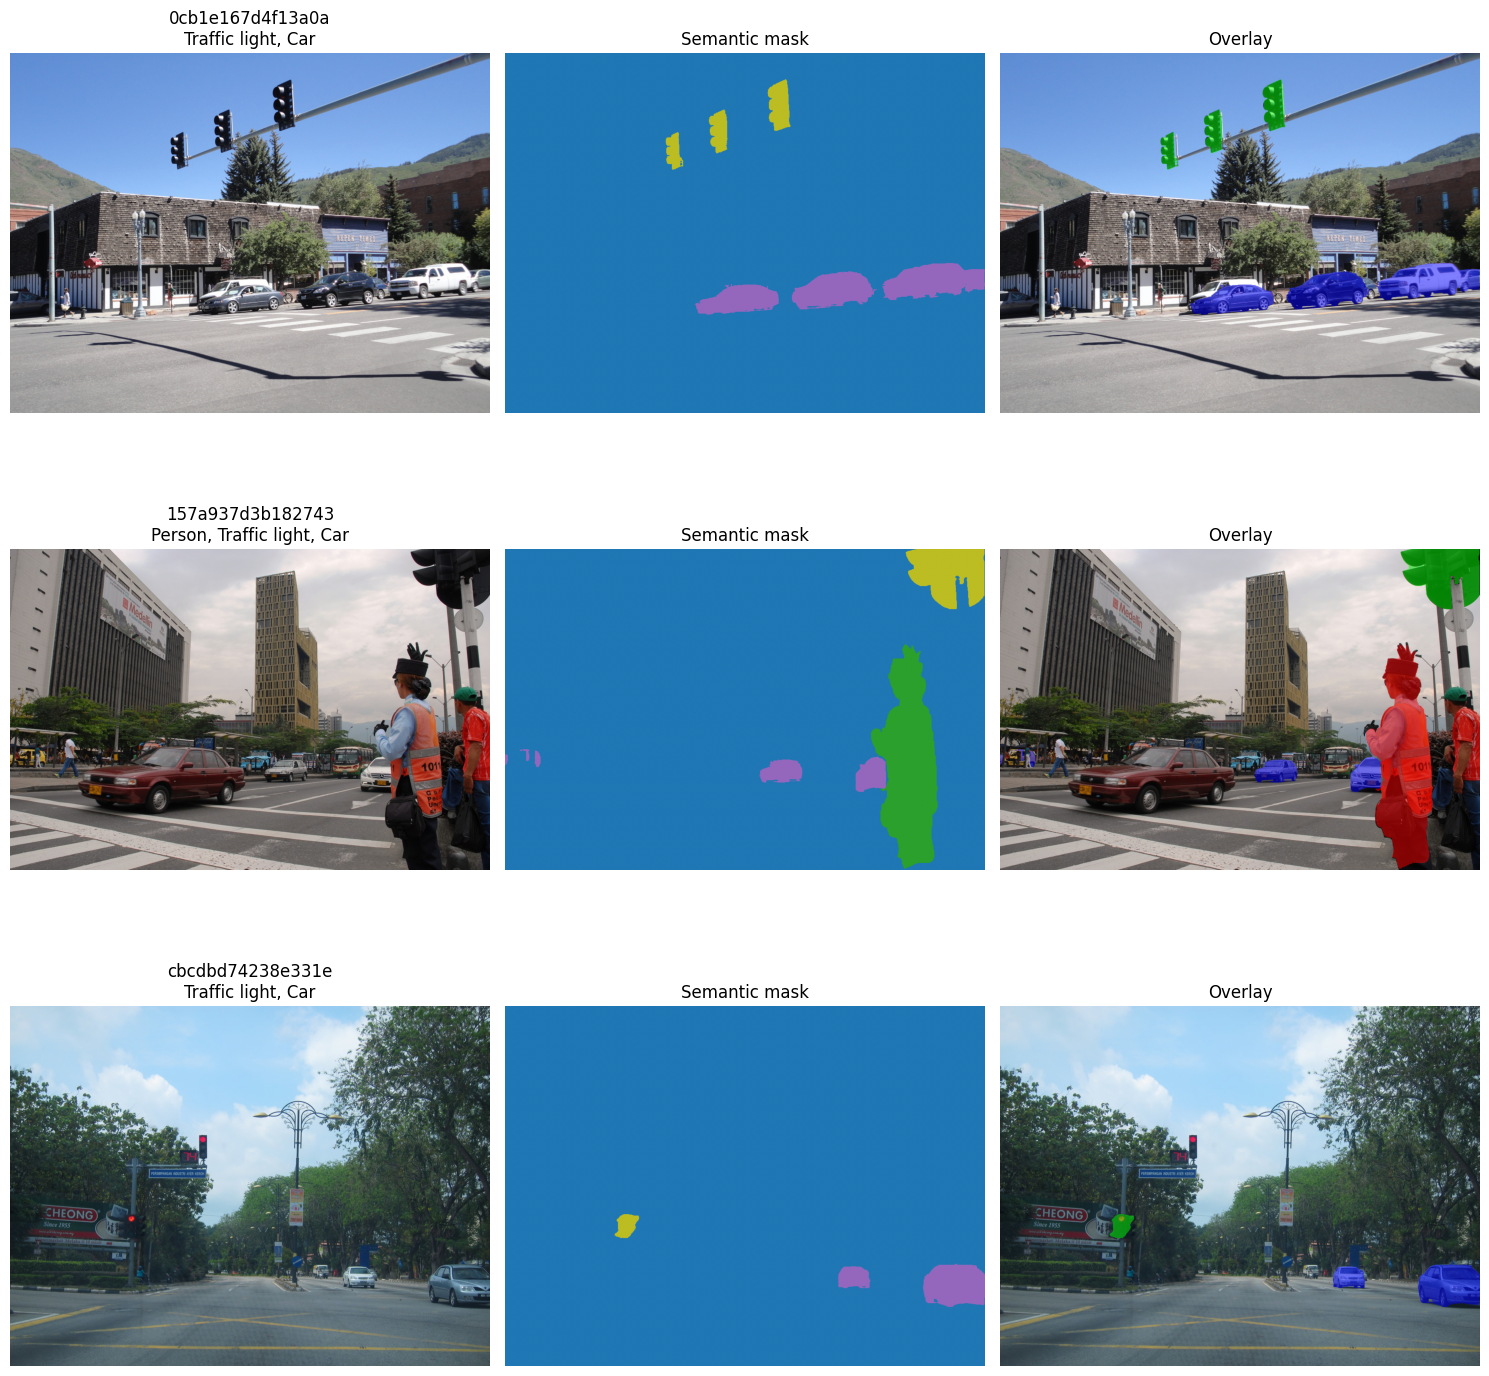

In [31]:
# pick a few random images that have multiple classes and then plot on them
random.seed(123)
def get_multi_class_samples(n=4):
    candidates = []
    for img_id in selected:
        classes = set(a['class_name'] for a in all_annots[img_id])
        if len(classes) >= 2: # find images with 2+ classes for more interestig/meaningful visuals
            candidates.append(img_id)
    return random.sample(candidates, min(n, len(candidates)))

samples = get_multi_class_samples(3)

fig, axes = plt.subplots(len(samples), 3, figsize=(15, 5 * len(samples)))

for row, img_id in enumerate(samples):
    # load image
    img_path = os.path.join(IMAGES_DIR, f"{img_id}.jpg")
    img = Image.open(img_path)
    img_arr = np.array(img)
    h, w = img_arr.shape[:2]

    # create combined mask
    combined_mask = np.zeros((h, w), dtype=np.uint8)

    # class colors (for visualisation)
    colors = {
        1: [255, 0, 0], # person - red
        2: [0, 0, 255], # car - blue
        3: [255, 255, 0], # bus - yellow
        4: [0, 255, 0], # traffic light - green
        5: [255, 0, 255], # skyscraper - pink
    }

    classes_in_image = []

    for a in all_annots[img_id]:
        mask_path = os.path.join(MASKS_DIR, a['mask_path'])
        if not os.path.exists(mask_path):
            print(f"missing: {mask_path}") # in case no mask was loaded/downloaded
            continue

        # load instance mask (full image size, just different resolution)
        mask = Image.open(mask_path)

        # resize mask to match image dimensions
        mask_resized = mask.resize((w, h), Image.NEAREST)
        mask_arr = np.array(mask_resized)

        # paint into combined mask (true pixels get class label)
        combined_mask[mask_arr > 0] = a['label_id']

        classes_in_image.append(a['class_name'])

    # coloured overlay
    overlay = np.zeros_like(img_arr)
    for label_id, color in colors.items():
        overlay[combined_mask == label_id] = color

    # blend
    alpha = 0.5
    blended = (img_arr * (1 - alpha) + overlay * alpha).astype(np.uint8)
    blended[combined_mask == 0] = img_arr[combined_mask == 0]

    # plot
    axes[row, 0].imshow(img_arr)
    axes[row, 0].set_title(f"{img_id}\n{', '.join(set(classes_in_image))}")
    axes[row, 0].axis('off')

    axes[row, 1].imshow(combined_mask, cmap='tab10', vmin=0, vmax=5)
    axes[row, 1].set_title("Semantic mask")
    axes[row, 1].axis('off')

    axes[row, 2].imshow(blended)
    axes[row, 2].set_title("Overlay")
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()